In [77]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns

In [70]:
df2015 = pd.read_csv(r'world-happiness/2015.csv').sort_values(by='Country').reset_index(drop=True)

df2015.shape

(158, 12)

### World Happiness in 2015
Here I only inspect data in 2015, but we can always do the same for other years

In [73]:
# Load the world map shapefile using Geopandas
world = gpd.read_file('natural-earth-lowres.zip')

In [61]:
w = world.sort_values(by="NAME").reset_index(drop=True)["NAME"]
w.shape

(177,)

In [ ]:
s = df2015['Country']
notin = ~w.isin(s)
w[notin] # check if any mismatch name T_T and replace in data by hand
# All country or region below are actully doesn't exist in dataset

4                  Antarctica
10                    Bahamas
14                     Belize
21                     Brunei
28       Central African Rep.
36                       Cuba
39              Côte d'Ivoire
48                    Eritrea
51               Falkland Is.
52                       Fiji
54     Fr. S. Antarctic Lands
57                     Gambia
62                  Greenland
64                     Guinea
65              Guinea-Bissau
66                     Guyana
107                   Namibia
110             New Caledonia
115               North Korea
116           North Macedonia
122          Papua New Guinea
128               Puerto Rico
133                  S. Sudan
140               Solomon Is.
141                   Somalia
156               Timor-Leste
169                   Vanuatu
172                 W. Sahara
176                  eSwatini
Name: NAME, dtype: object

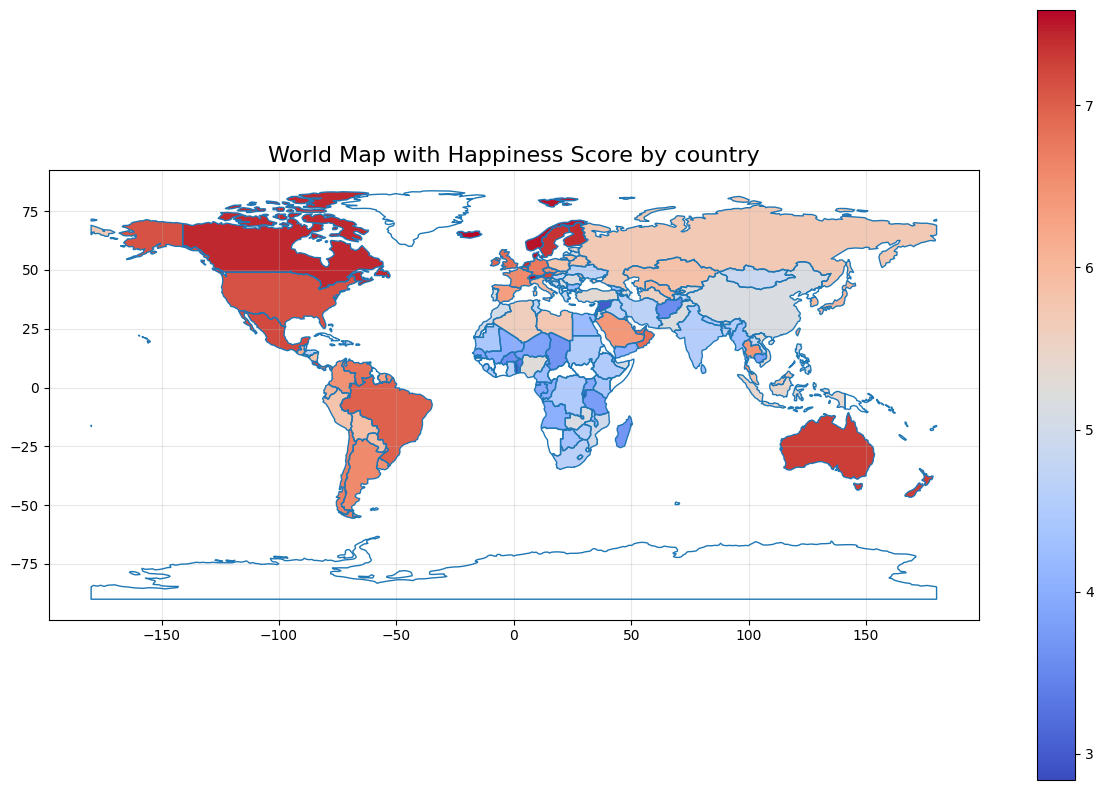

In [74]:
column_to_plot = 'Happiness Score'

data_df = df2015[['Country', column_to_plot]]

# Merge the data with the world GeoDataFrame on the Country name
world = world.merge(data_df, how='left', left_on='NAME', right_on='Country')

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world.boundary.plot(ax=ax, linewidth=1)  # Optional: Show country boundaries
world.plot(column=column_to_plot, cmap='coolwarm', legend=True, ax=ax)

# Add title and adjust layout
ax.set_title(f"World Map with {column_to_plot} by country", fontsize=16)
# ax.axis("off")  # Turn off axes for better visualization
ax.grid(alpha=0.3)
plt.show()


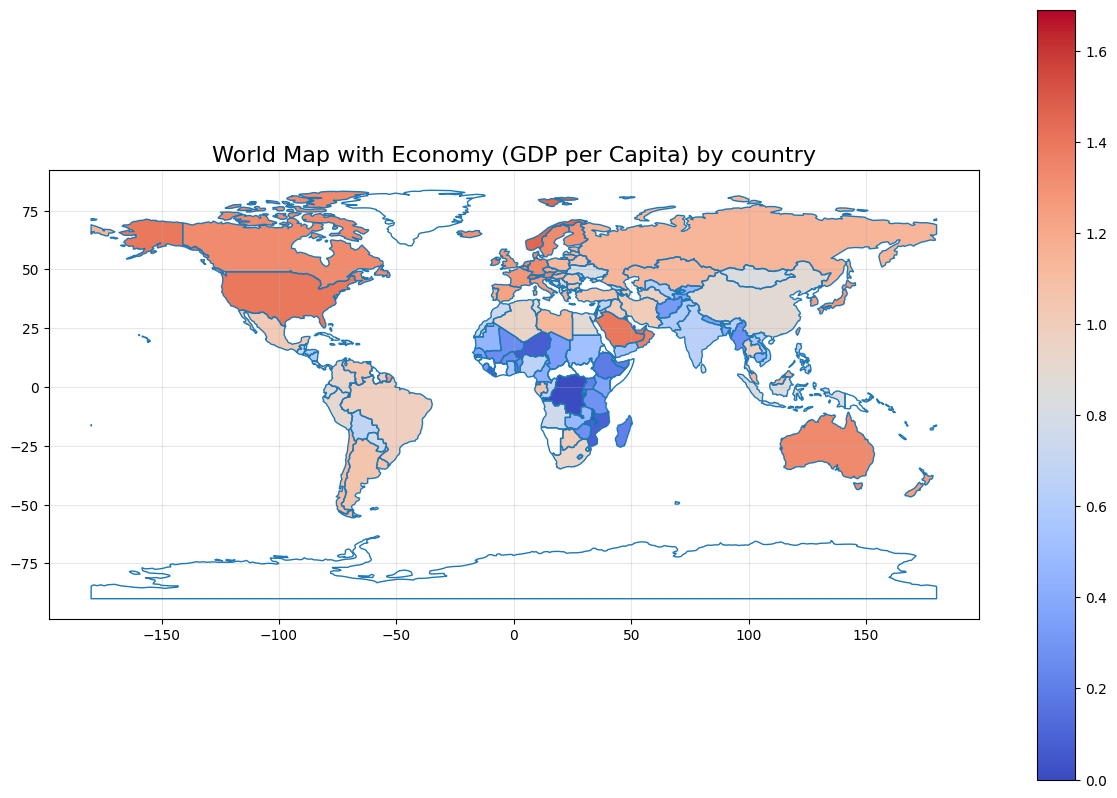

In [75]:
column_to_plot = 'Economy (GDP per Capita)'

data_df = df2015[['Country', column_to_plot]]

# Merge the data with the world GeoDataFrame on the ISO country codes
world = world.merge(data_df, how='left', left_on='NAME', right_on='Country')

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world.boundary.plot(ax=ax, linewidth=1)  # Optional: Show country boundaries
world.plot(column=column_to_plot, cmap='coolwarm', legend=True, ax=ax)

# Add title and adjust layout
ax.set_title(f"World Map with {column_to_plot} by country", fontsize=16)
# ax.axis("off")  # Turn off axes for better visualization
ax.grid(alpha=0.3)
plt.show()


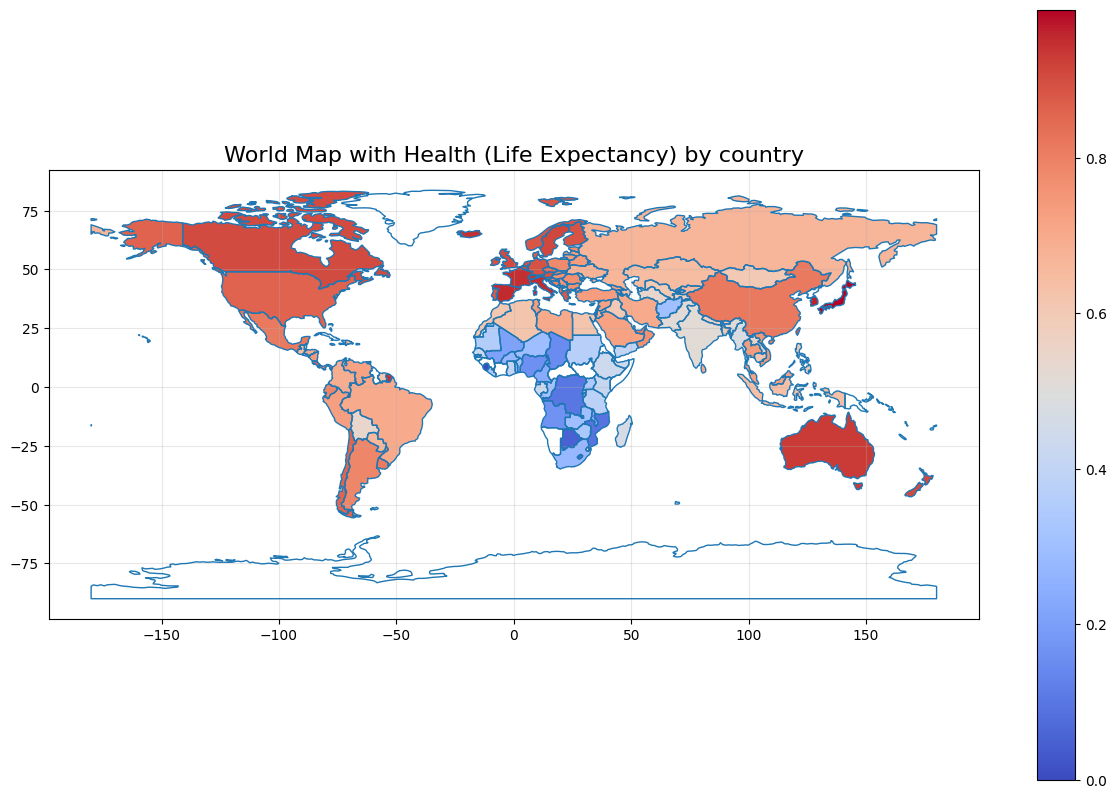

In [80]:
column_to_plot = 'Health (Life Expectancy)'

data_df = df2015[['Country', column_to_plot]]

# Merge the data with the world GeoDataFrame on the ISO country codes
world = world.merge(data_df, how='left', left_on='NAME', right_on='Country')

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world.boundary.plot(ax=ax, linewidth=1)  # Optional: Show country boundaries
world.plot(column=column_to_plot, cmap='coolwarm', legend=True, ax=ax)

# Add title and adjust layout
ax.set_title(f"World Map with {column_to_plot} by country", fontsize=16)
# ax.axis("off")  # Turn off axes for better visualization
ax.grid(alpha=0.3)
plt.show()

__COMMENT ON THE PLOT__ <br>
- We can see that most of the country with high happiness score are in western region. <br>
- We can also notice that countries with high GDP and health quality tend to have higher happiness score, indicate a level of correlation. We check that with below correlation map.

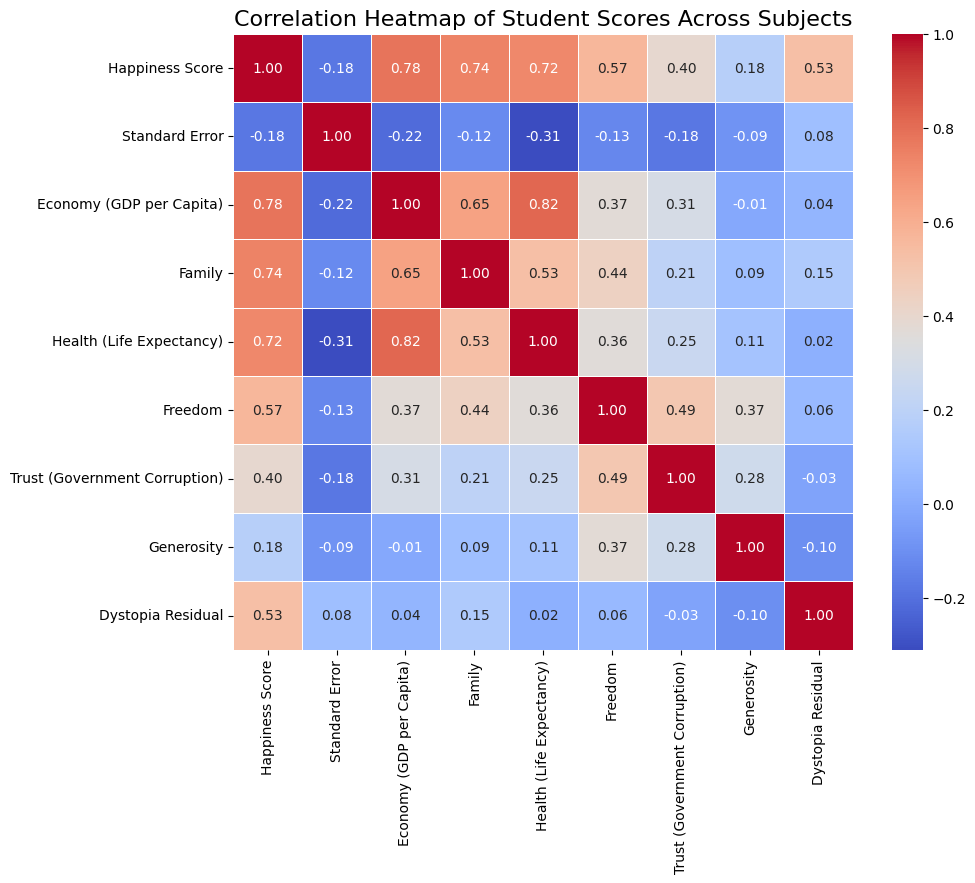

In [83]:
corr_df = df2015.drop(df2015.columns[:3], axis=1)
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Heatmap of Student Scores Across Subjects', fontsize=16)
plt.show()

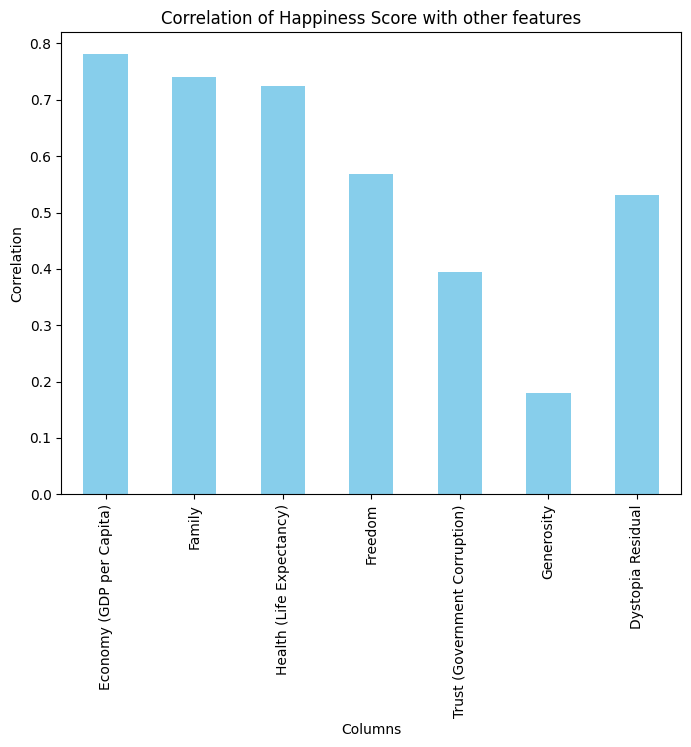

In [88]:
plt.figure(figsize=(8, 6))
corr_matrix["Happiness Score"].drop(["Happiness Score", "Standard Error"], axis='index').plot(kind='bar', color='skyblue')  # Drop 'A' to avoid self-correlation
plt.title('Correlation of Happiness Score with other features')
plt.xlabel('Columns')
plt.ylabel('Correlation')
plt.show()

In [91]:
df2015['Region'].unique()

array(['Southern Asia', 'Central and Eastern Europe',
       'Middle East and Northern Africa', 'Sub-Saharan Africa',
       'Latin America and Caribbean', 'Australia and New Zealand',
       'Western Europe', 'Southeastern Asia', 'North America',
       'Eastern Asia'], dtype=object)

Text(0, 0.5, 'Mean Value')

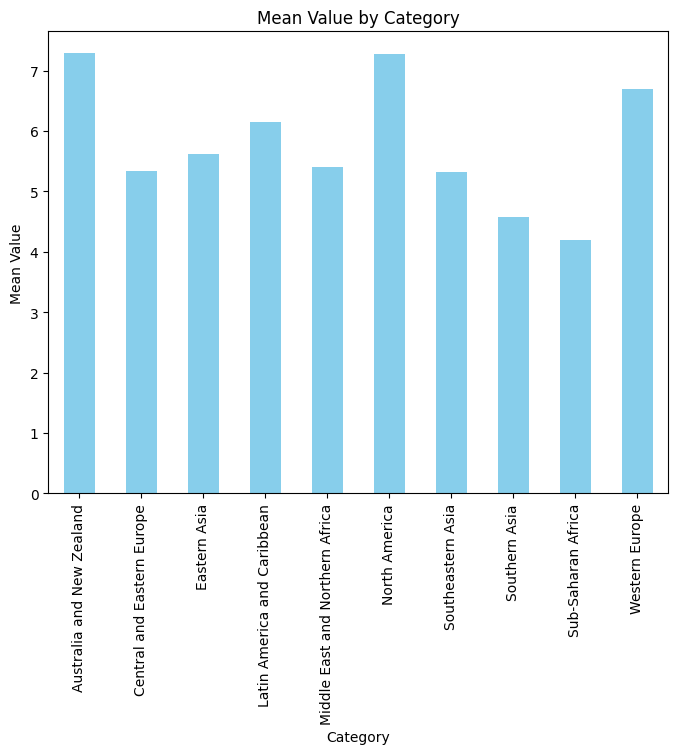

In [ ]:
mean_values = df2015.groupby('Region')['Happiness Score'].mean()

# Plotting the mean values as a bar chart
plt.figure(figsize=(8, 6))
mean_values.plot(kind='bar', color='skyblue')

# Adding titles and labels
plt.title('Mean Hapiness Score by region')
plt.xlabel('Region')
plt.ylabel('Happiness Score')

__COMMENT ON PLOT__ <br>
Indeed Western Europe, North America, Australia and New Zealand have the highest happiness score